# Practical Work 4 — Multilayer Perceptron Learning

**Datasets:** `adult.csv` (Adult Census Income), `tested.csv` (Titanic)

**Tasks:** Preprocessing → Imputation → Normalization → PCA → MLP (hidden layers, activation functions) → Loss curves & accuracy comparison

## 1. Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# Datasets are in the same folder as this notebook (pw4)
adult_path = 'adult.csv'
titanic_path = 'tested.csv'

# Load Adult Census dataset (primary)
df_adult = pd.read_csv(adult_path)
print("Adult Census:", df_adult.shape)
df_adult.head()

Adult Census: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 2. Data Preprocessing — Missing Values, Duplicates, Outliers

**Adult dataset:** `?` denotes missing values in workclass, occupation, native.country.

In [2]:
# Replace '?' with NaN for proper missing value handling
df = df_adult.copy()
df = df.replace('?', np.nan)

print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Missing values per column:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

Duplicates: 24
After removing duplicates: (32537, 15)


In [3]:
# Outliers: IQR method for numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = ((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
print("Rows with outliers (IQR):", outlier_mask.sum())
# Option: cap outliers instead of removing (preserve data size)
df_clean = df.copy()
for col in num_cols:
    df_clean[col] = df_clean[col].clip(lower=Q1[col] - 1.5*IQR[col], upper=Q3[col] + 1.5*IQR[col])

Rows with outliers (IQR): 13554


## 3. Imputation — Mean, Median, KNN

For numerical columns with missing values we compare strategies. Adult has no numerical NaNs; we'll use Titanic for Age/Fare. For Adult: impute categorical (workclass, occupation, native.country) with mode.

In [4]:
# Categorical imputation (Adult): use mode
cat_cols = ['workclass', 'occupation', 'native.country']
for c in cat_cols:
    mode_val = df_clean[c].mode()[0] if df_clean[c].mode().size else 'Unknown'
    df_clean[c] = df_clean[c].fillna(mode_val)
print("After categorical imputation, missing:", df_clean.isnull().sum().sum())

After categorical imputation, missing: 0


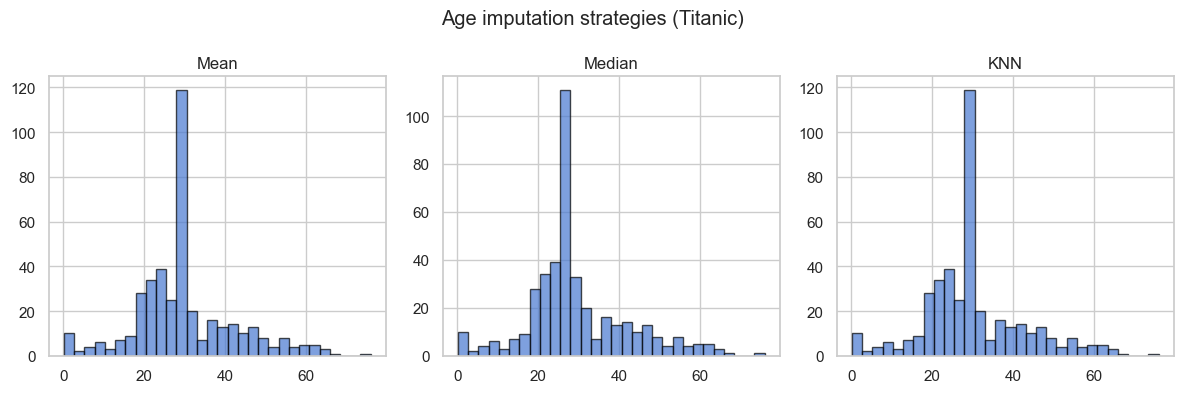

In [5]:
# Titanic: numerical imputation (Age, Fare) — compare Mean, Median, KNN
df_titanic = pd.read_csv(titanic_path)
df_titanic['Age'] = pd.to_numeric(df_titanic['Age'], errors='coerce')
df_titanic['Fare'] = pd.to_numeric(df_titanic['Fare'], errors='coerce')

age_mean = df_titanic['Age'].fillna(df_titanic['Age'].mean())
age_median = df_titanic['Age'].fillna(df_titanic['Age'].median())
knn = KNNImputer(n_neighbors=5)
age_knn = pd.Series(knn.fit_transform(df_titanic[['Age']]).ravel(), index=df_titanic.index)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].hist(age_mean.dropna(), bins=30, edgecolor='black', alpha=0.7); axes[0].set_title('Mean')
axes[1].hist(age_median.dropna(), bins=30, edgecolor='black', alpha=0.7); axes[1].set_title('Median')
axes[2].hist(age_knn, bins=30, edgecolor='black', alpha=0.7); axes[2].set_title('KNN')
plt.suptitle('Age imputation strategies (Titanic)'); plt.tight_layout(); plt.show()

## 4. Normalization — MinMax vs Z-score, Distribution Comparison

Prepare numerical features for Adult, then apply MinMax and StandardScaler (Z-score).

In [6]:
# Encode categoricals (each column gets its own LabelEncoder)
df_enc = df_clean.copy()
for c in df_enc.select_dtypes(include=['object']).columns:
    if c != 'income':
        df_enc[c] = LabelEncoder().fit_transform(df_enc[c].astype(str))
df_enc['income'] = (df_enc['income'] == '>50K').astype(int)

X_num = df_enc[num_cols].copy()
X_minmax = MinMaxScaler().fit_transform(X_num)
X_zscore = StandardScaler().fit_transform(X_num)

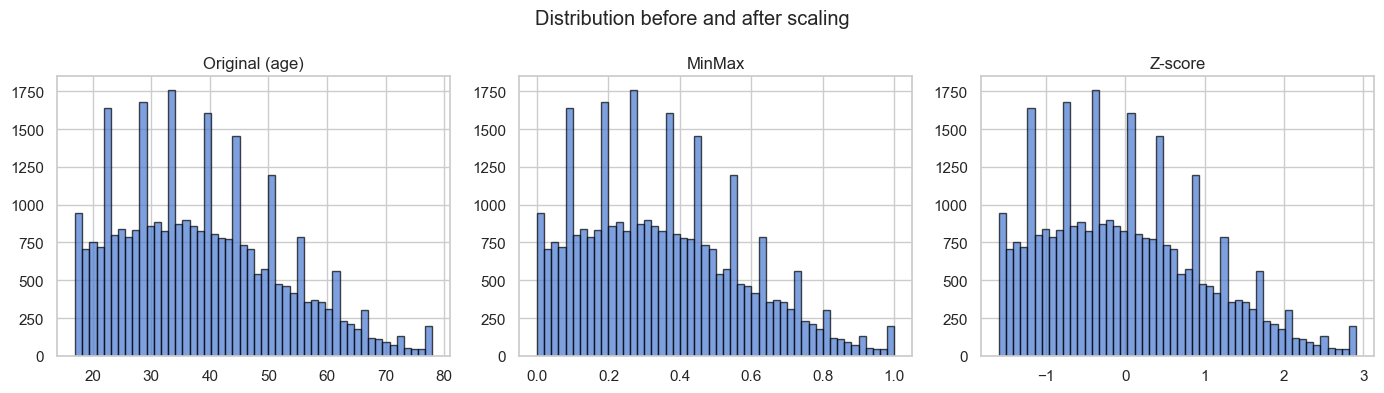

In [7]:
# Compare distributions before and after scaling (example: age)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(X_num['age'], bins=50, edgecolor='black', alpha=0.7); axes[0].set_title('Original (age)')
axes[1].hist(X_minmax[:, 0], bins=50, edgecolor='black', alpha=0.7); axes[1].set_title('MinMax')
axes[2].hist(X_zscore[:, 0], bins=50, edgecolor='black', alpha=0.7); axes[2].set_title('Z-score')
plt.suptitle('Distribution before and after scaling'); plt.tight_layout(); plt.show()

## 5. PCA — Cumulative Explained Variance

Standardize features and apply PCA, then plot cumulative explained variance.

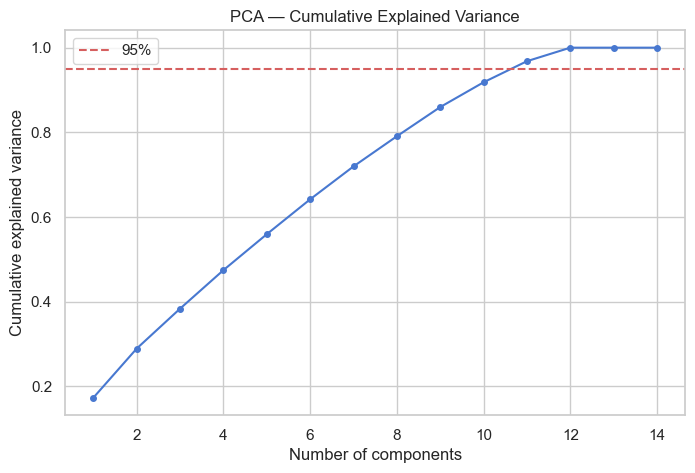

Components for 95% variance: 11


In [8]:
# Full feature matrix (all encoded columns except target)
X_full = df_enc.drop(columns=['income'])
y = df_enc['income']
X_scaled = StandardScaler().fit_transform(X_full)

pca = PCA().fit(X_scaled)
cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumvar)+1), cumvar, 'b-o', markersize=4)
plt.axhline(0.95, color='r', linestyle='--', label='95%')
plt.xlabel('Number of components'); plt.ylabel('Cumulative explained variance')
plt.title('PCA — Cumulative Explained Variance'); plt.legend(); plt.grid(True); plt.show()
print("Components for 95% variance:", np.argmax(cumvar >= 0.95) + 1)

## 6. MLP — Hidden Layers (10,20), (50), Activation Functions (ReLU, Tanh, Sigmoid)

Train multiple MLPs and compare training vs testing accuracy. Use standardized features.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

configs = [
    {'hidden': (10, 20), 'act': 'relu'},
    {'hidden': (10, 20), 'act': 'tanh'},
    {'hidden': (10, 20), 'act': 'logistic'},
    {'hidden': (50,), 'act': 'relu'},
    {'hidden': (50,), 'act': 'tanh'},
    {'hidden': (50,), 'act': 'logistic'},
]
results = []
for cfg in configs:
    clf = MLPClassifier(hidden_layer_sizes=cfg['hidden'], activation=cfg['act'], max_iter=500, random_state=42)
    clf.fit(X_train, y_train)
    tr_acc = accuracy_score(y_train, clf.predict(X_train))
    te_acc = accuracy_score(y_test, clf.predict(X_test))
    results.append({'hidden': str(cfg['hidden']), 'activation': cfg['act'], 'train_acc': tr_acc, 'test_acc': te_acc})
pd.DataFrame(results)

,hidden,activation,train_acc,test_acc
0,"(10, 20)",relu,0.839717,0.828211
1,"(10, 20)",tanh,0.836413,0.831285
2,"(10, 20)",logistic,0.834339,0.833436
3,"(50,)",relu,0.842407,0.834204
4,"(50,)",tanh,0.849860,0.832667
5,"(50,)",logistic,0.840409,0.838506


## 7. Training Loss Curve

Plot the loss curve for an MLP model during training.

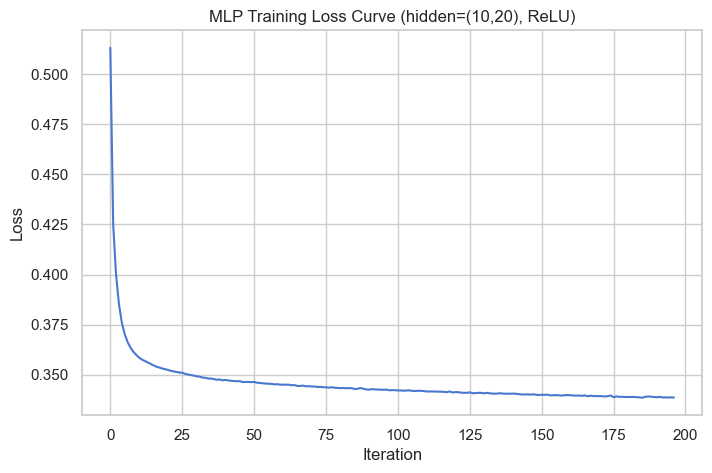

In [10]:
mlp = MLPClassifier(hidden_layer_sizes=(10, 20), activation='relu', max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, 'b-')
plt.xlabel('Iteration'); plt.ylabel('Loss')
plt.title('MLP Training Loss Curve (hidden=(10,20), ReLU)'); plt.grid(True); plt.show()

## 8. Training vs Testing Accuracy — Bar Chart

Compare training and testing accuracy across all configurations.

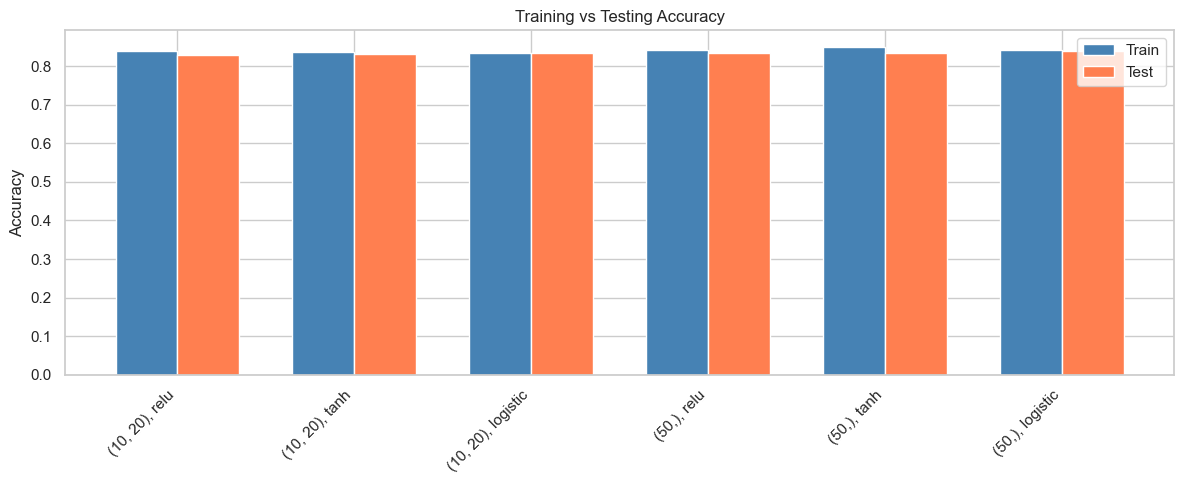

In [11]:
res_df = pd.DataFrame(results)
res_df['config'] = res_df['hidden'] + ', ' + res_df['activation']
x = np.arange(len(res_df))
w = 0.35
plt.figure(figsize=(12, 5))
plt.bar(x - w/2, res_df['train_acc'], w, label='Train', color='steelblue')
plt.bar(x + w/2, res_df['test_acc'], w, label='Test', color='coral')
plt.xticks(x, res_df['config'], rotation=45, ha='right')
plt.ylabel('Accuracy'); plt.legend(); plt.title('Training vs Testing Accuracy'); plt.tight_layout(); plt.show()

## 9. (Optional) Titanic — Quick MLP

Same pipeline on Titanic: impute Age/Fare, encode, scale, train MLP.

In [12]:
# Titanic: prepare features (tested.csv may have '5PassengerId' due to encoding)
dt = df_titanic.copy()
dt.columns = [c.lstrip('0123456789') if c[0].isdigit() else c for c in dt.columns]  # fix '5PassengerId' -> 'PassengerId'
dt['Age'] = dt['Age'].fillna(dt['Age'].median())
dt['Fare'] = dt['Fare'].fillna(dt['Fare'].median())
dt['Embarked'] = dt['Embarked'].fillna(dt['Embarked'].mode()[0])
cols_drop = [c for c in ['PassengerId', 'Name', 'Ticket', 'Cabin'] if c in dt.columns]
dt = dt.drop(columns=cols_drop)
dt['Sex'] = (dt['Sex'] == 'male').astype(int)
dt['Embarked'] = LabelEncoder().fit_transform(dt['Embarked'].astype(str))
Xt = dt.drop(columns=['Survived'])
yt = dt['Survived']
Xt_scaled = StandardScaler().fit_transform(Xt)
Xt_train, Xt_test, yt_train, yt_test = train_test_split(Xt_scaled, yt, test_size=0.2, random_state=42, stratify=yt)
mlp_t = MLPClassifier(hidden_layer_sizes=(10, 20), activation='relu', max_iter=500, random_state=42)
mlp_t.fit(Xt_train, yt_train)
print("Titanic — Train:", accuracy_score(yt_train, mlp_t.predict(Xt_train)), "Test:", accuracy_score(yt_test, mlp_t.predict(Xt_test)))

Titanic — Train: 1.0 Test: 1.0


---

## Summary Report

- **Preprocessing:** Replaced `?` with NaN, removed duplicates, capped outliers (IQR).
- **Imputation:** Categorical (mode) for Adult; Mean/Median/KNN compared for Titanic Age.
- **Normalization:** MinMax and Z-score applied; distributions compared.
- **PCA:** Cumulative explained variance plotted; components for 95% variance reported.
- **MLP:** Trained with hidden (10,20) and (50), activations ReLU/Tanh/Logistic.
- **Results:** Training loss curve and train vs test accuracy bar chart.